# Explore Hot Spots for Population and Air Data
Using clean data file explore where in study area are there hotspots - places with high HAP concentration, high population exposure and high exposure with populations that are low income renters.


## Description of Program
- program:    ip1_3av1_hotspotspopair_2026-03-03
- task:       Hotspots
- Version:    2026-03-03
- project:    Southeast Texas Urban Integrated Field Lab
- funding:	  DOE
- author:     Nathanael Rosenheim

## Step 0: Good Housekeeping

In [1]:
# 1. Import all packages
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd  # For working with geospatial data
import os                # For file path management
import matplotlib.pyplot as plt # For plotting
import contextily as ctx # For adding basemaps

# load the common functions for this project
from ip1_1av1_common import *

In [2]:
# 2. Check versions
import sys
print("Python Version     ", sys.version)
print("pandas version: ", pd.__version__)

Python Version      3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:12:41) [MSC v.1944 64 bit (AMD64)]
pandas version:  2.3.3


In [3]:
# 3. Check working directory
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\integrate_people_theme1_cookbook'

In [4]:
#4. Store Program Name for output files to have the same name
programname = "ip1_3av1_hotspotspopair"
# Make directory to save output
if not os.path.exists(programname):
    os.mkdir(programname)

# Step 1: Obtain Data

Cleaned Data with Population and Air Data Combined

In [5]:
source_programname = "ip1_2cv2_popair"
source_filename = f"{source_programname}.gpkg"

popair_gdf = gpd.read_file(os.path.join(source_programname, source_filename))
popair_gdf.head(1)

,huid,Block2020,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,...,uifl_4km_Xylenes_p100,uifl_4km_Xylenes_p50,uifl_4km_Xylenes_p99,uifl_4km_Xylenes_p98,uifl_4km_Xylenes_mean,uifl_4km_Xylenes_p75,uifl_4km_Xylenes_p25,uifl_4km_Xylenes_p90,uifl_4km_Xylenes_p95,geometry
0,B481990302002008H002,481990302002008,481990302002008,481990302002,48199030200,48199.0,0.0,NaN,NaN,NaN,...,0.109007,0.00692,0.072622,0.061573,0.011893,0.015375,0.001948,0.029066,0.04408,POINT (-94.41106 30.13976)


# Step 2: Clean Data

# Step 3: Explore Data

In [6]:
'''
pollutant = "uifl_1km_Benzene_p95"
# map hua point data with air pollution values
fig, ax = plt.subplots(figsize=(10, 8))
popair_gdf.plot(column=f'{pollutant}', ax=ax, legend=True,
                 cmap='viridis', markersize=5,
                 legend_kwds={'label': f'{pollutant} (ppb)', 'shrink': 0.6})
ctx.add_basemap(ax, crs=popair_gdf.crs, source=ctx.providers.CartoDB.Positron)
plt.title(f"Spatial Distribution of {pollutant} at Housing Units")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
'''

'\npollutant = "uifl_1km_Benzene_p95"\n# map hua point data with air pollution values\nfig, ax = plt.subplots(figsize=(10, 8))\npopair_gdf.plot(column=f\'{pollutant}\', ax=ax, legend=True,\n                 cmap=\'viridis\', markersize=5,\n                 legend_kwds={\'label\': f\'{pollutant} (ppb)\', \'shrink\': 0.6})\nctx.add_basemap(ax, crs=popair_gdf.crs, source=ctx.providers.CartoDB.Positron)\nplt.title(f"Spatial Distribution of {pollutant} at Housing Units")\nplt.xlabel("Longitude")\nplt.ylabel("Latitude")\nplt.show()\n'

## Step 4: Hotspot Analysis - Contour Maps

Create contour maps to identify hotspots using moving window density estimation:
1. **Total Population Density** - Where are people concentrated?
2. **Demographic Distribution** - Where are vulnerable populations (low income renters) vs. affluent populations (high income homeowners)?
3. **Pollutant-Weighted Population** - Where is exposure highest (population × pollutant concentration)?

**Configuration Parameters:**
- Adjust `low_income_percentile` and `high_income_percentile` to change demographic thresholds
  - Current: 25th/75th percentile (quartile-based)
  - Alternative: 10th/90th percentile for more extreme groups
- Change `pollutant` variable to analyze different HAPs (e.g., "uifl_1km_Toluene_mean")
- **Contour Increment Approach**: Use `contour_increment` to specify the population increment between contour lines
  - e.g., `contour_increment = 100` creates contours at 100, 200, 300, ... people
  - e.g., `contour_increment = 50` creates contours at 50, 100, 150, ... people
  - Each contour line represents a clean increment rather than a fixed number of levels
- Raster parameters: 400m cell size, 500m smoothing window

In [7]:
# Configure analysis parameters
# Income percentiles for demographic classification
low_income_percentile = 0.25  # 25th percentile (first quartile)
high_income_percentile = 0.75  # 75th percentile (third quartile)

# Contour parameters (from DEFAULT_CONTOUR_PARAMS configuration)
cell_size_m = 400  # Raster cell size in meters
window_radius_m = 500  # Moving window radius in meters

# Use clean increments for contour levels
# Each contour line represents this many additional people
contour_increment = 100  # e.g., contours at 100, 200, 300, 400, ... people

pollutant = "uifl_1km_Benzene_mean"

print(f"Analysis Configuration:")
print(f"  Pollutant: {pollutant}")
print(f"  Low income threshold: {low_income_percentile*100:.0f}th percentile")
print(f"  High income threshold: {high_income_percentile*100:.0f}th percentile")
print(f"  Contour parameters: cell={cell_size_m}m, window={window_radius_m}m, increment={contour_increment}")
print(f"  Note: Actual contour levels will be calculated based on max values in data")

Analysis Configuration:
  Pollutant: uifl_1km_Benzene_mean
  Low income threshold: 25th percentile
  High income threshold: 75th percentile
  Contour parameters: cell=400m, window=500m, increment=100
  Note: Actual contour levels will be calculated based on max values in data


### 4.0 Filter Demographic Groups

Classify households by income and tenure for targeted analysis.

In [8]:
# Filter data into demographic groups
demographic_groups = filter_demographic_groups(
    popair_gdf, 
    low_income_percentile=low_income_percentile,
    high_income_percentile=high_income_percentile
)

# Display threshold information
thresholds = demographic_groups["thresholds"]
counts = demographic_groups["counts"]

print(f"\nDemographic Filtering Results:")
print(f"  Total households: {counts['total']:,}")
print(f"\n  Low Income Threshold (≤{int(thresholds['low_percentile']*100)}th percentile): ${thresholds['low']:,.2f}")
print(f"    Low Income Renters: {counts['low_income_renters']:,} households ({counts['low_income_renters']/counts['total']*100:.1f}%)")
print(f"\n  High Income Threshold (≥{int(thresholds['high_percentile']*100)}th percentile): ${thresholds['high']:,.2f}")
print(f"    High Income Homeowners: {counts['high_income_homeowners']:,} households ({counts['high_income_homeowners']/counts['total']*100:.1f}%)")


Demographic Filtering Results:
  Total households: 192,639

  Low Income Threshold (≤25th percentile): $29,765.00
    Low Income Renters: 16,557 households (8.6%)

  High Income Threshold (≥75th percentile): $112,202.25
    High Income Homeowners: 31,884 households (16.6%)


### 4.1 Total Population Density Contours

Identify areas with highest population concentration using moving window density estimation.

Building population density raster (cell=400m, window=500m)...
Calculated 28 contour levels (increment=100): 100 to 2800


c:\Users\nathanael99\AppData\Local\miniconda3\envs\ip1\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


Saved figure: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_total_population_contours.png


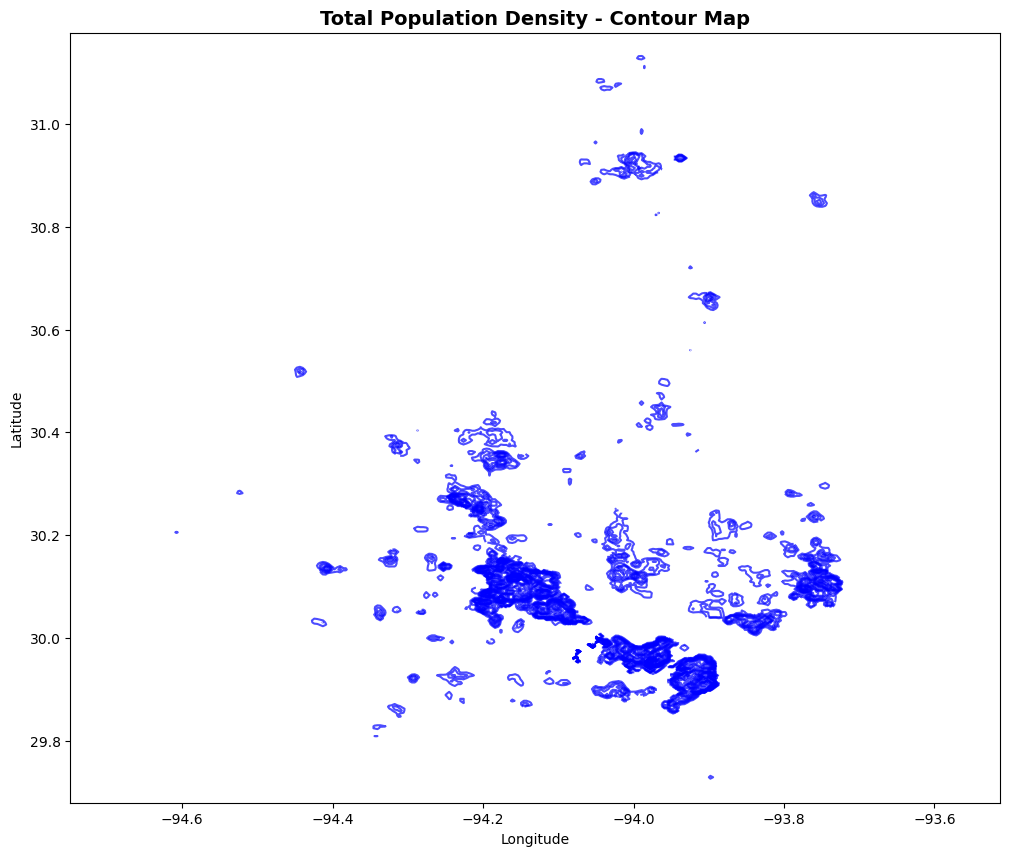

Converting contours to shapefile...
Saved shapefile: ip1_3av1_hotspotspopair\total_population_contours.shp


In [9]:
# Create total population contour map
pop_contours = create_population_contours(
    popair_gdf,
    output_dir=programname,
    programname=programname,
    cell_size_m=cell_size_m,
    window_radius_m=window_radius_m,
    contour_increment=contour_increment,
    save_shapefile=True
)

### 4.2 Demographic Distribution Contours

Compare spatial patterns of vulnerable populations (low income renters in blue) versus affluent populations (high income homeowners in red).

Building rasters for demographic groups...
  Low income renters: 16557 households (income <= $29,765)
  High income homeowners: 31884 households (income >= $112,202)
Calculated 12 contour levels (increment=100): 100 to 1200


c:\Users\nathanael99\AppData\Local\miniconda3\envs\ip1\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


Saved figure: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_demographics_contours.png


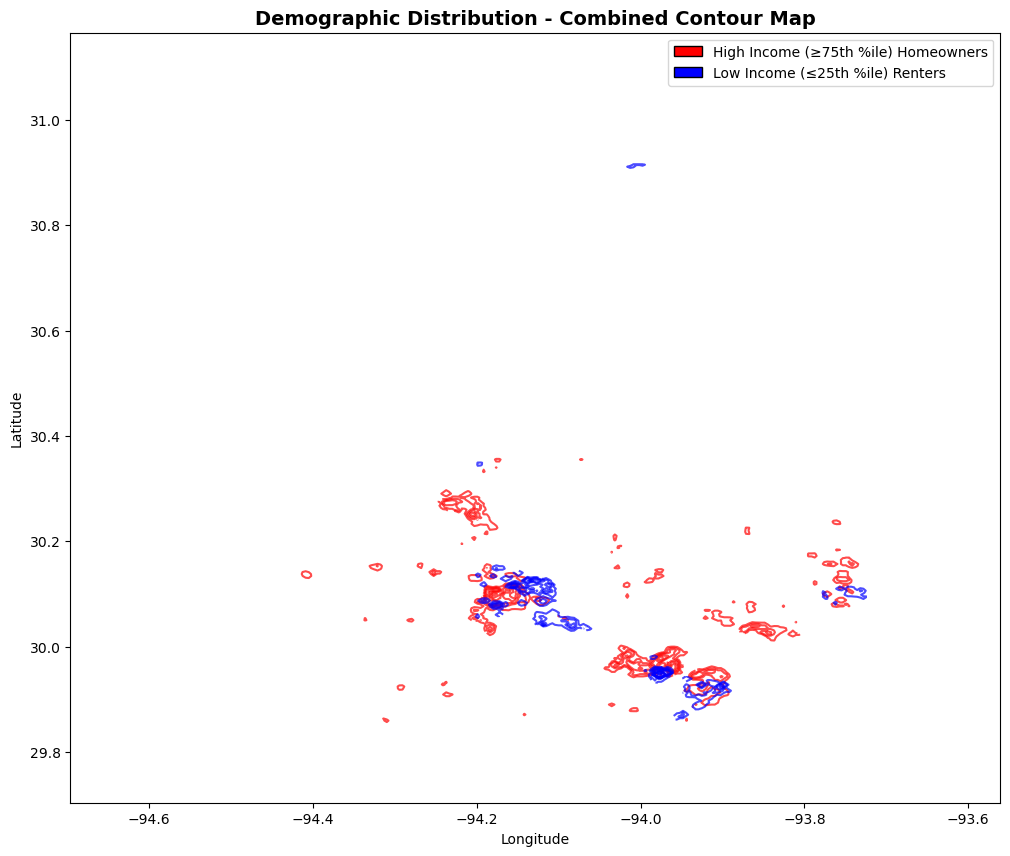

Converting contours to shapefiles...
Saved shapefile: ip1_3av1_hotspotspopair\low_income_renters_contours.shp
Saved shapefile: ip1_3av1_hotspotspopair\high_income_homeowners_contours.shp


In [10]:
# Create combined demographic contour map
demo_contours = create_demographic_contours(
    popair_gdf,
    demographic_groups=demographic_groups,
    output_dir=programname,
    programname=programname,
    cell_size_m=cell_size_m,
    window_radius_m=window_radius_m,
    contour_increment=contour_increment,
    save_shapefile=True
)

### 4.5 Testing Multiple Weighting Methods

Compare different weighting approaches (direct multiplication, z-score threshold, percentile threshold) to understand how different standardization methods affect hotspot identification.

**Weighting Methods:**
1. **Direct** (`wnpbmean`): population × pollutant concentration
2. **Z-Score** (`wnpbmeanz3`): Only areas significantly above mean (3 SD) contribute, zero-filled elsewhere
3. **Percentile** (`wnpbmeanp75`): Above 75th percentile normalized 0-1, zero-filled elsewhere

This cell generates all three weight columns for benzene.

In [11]:
# Generate all weight columns for Benzene using three methods
print("Generating weight columns for Benzene...")
popair_gdf = generate_all_weights_for_pollutant(
    popair_gdf,
    pollutant_column=pollutant,  # "uifl_1km_Benzene_mean"
    methods=['direct', 'zscore', 'percentile'],
    zscore_thresholds=[3],  # Can test multiple: [2, 3]
    percentile_thresholds=[75],  # Can test multiple: [50, 75]
    inplace=False
)

# Display the new columns
weight_cols = ['wnpBmean', 'wnpBmeanz3', 'wnpBmeanp75']
print(f"\nWeight columns created: {weight_cols}")
print(f"\nStatistics for each weight column:")
for col in weight_cols:
    print(f"\n{col}:")
    print(f"  Count: {popair_gdf[col].count()}")
    print(f"  Min: {popair_gdf[col].min():.4f}")
    print(f"  Max: {popair_gdf[col].max():.4f}")
    print(f"  Mean: {popair_gdf[col].mean():.4f}")
    print(f"  Std: {popair_gdf[col].std():.4f}")
    print(f"  Non-zero: {(popair_gdf[col] > 0).sum()} ({(popair_gdf[col] > 0).sum()/len(popair_gdf)*100:.1f}%)")

Generating weight columns for Benzene...

Generating weights for uifl_1km_Benzene_mean (B-mean)

--- Direct Weighting ---
Created: wnpBmean
  Range: 0.0000 to 83.0442
  Mean: 0.0768

--- Z-Score Weighting ---
Created: wnpBmeanz3 (threshold: 3 SD above mean)
  Mean: 0.0330, Std: 0.0081
  Threshold value: 0.0572
  Non-zero cells: 1009 / 192639 (0.5%)
  Range: 0.0000 to 139.4936
  Mean: 0.0525

--- Percentile Weighting ---
Created: wnpBmeanp75 (threshold: 75th percentile)
  Threshold value: 0.0361
  Max value: 0.2437
  Non-zero cells: 31256 / 192639 (16.2%)
  Range: 0.0000 to 51.5861
  Mean: 0.0172

Summary: Created 3 weight column(s)
Columns: wnpBmean, wnpBmeanz3, wnpBmeanp75


Weight columns created: ['wnpBmean', 'wnpBmeanz3', 'wnpBmeanp75']

Statistics for each weight column:

wnpBmean:
  Count: 147237
  Min: 0.0000
  Max: 83.0442
  Mean: 0.0768
  Std: 0.4222
  Non-zero: 130027 (67.5%)

wnpBmeanz3:
  Count: 147237
  Min: 0.0000
  Max: 139.4936
  Mean: 0.0525
  Std: 1.2923
  Non-zero: 1

#### 4.5.1 Create Contours for Each Weight Method


Creating contours for DIRECT weight method (wnpBmean)
Building wnpBmean weighted contours for demographic groups (Percentile (Bmeanth))...
  Low income renters: 16557 households
  High income homeowners: 31884 households
Calculated 4 contour levels (increment=10): 10 to 40


c:\Users\nathanael99\AppData\Local\miniconda3\envs\ip1\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


Saved figure: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_weighted_demographics_wnpBmean.png


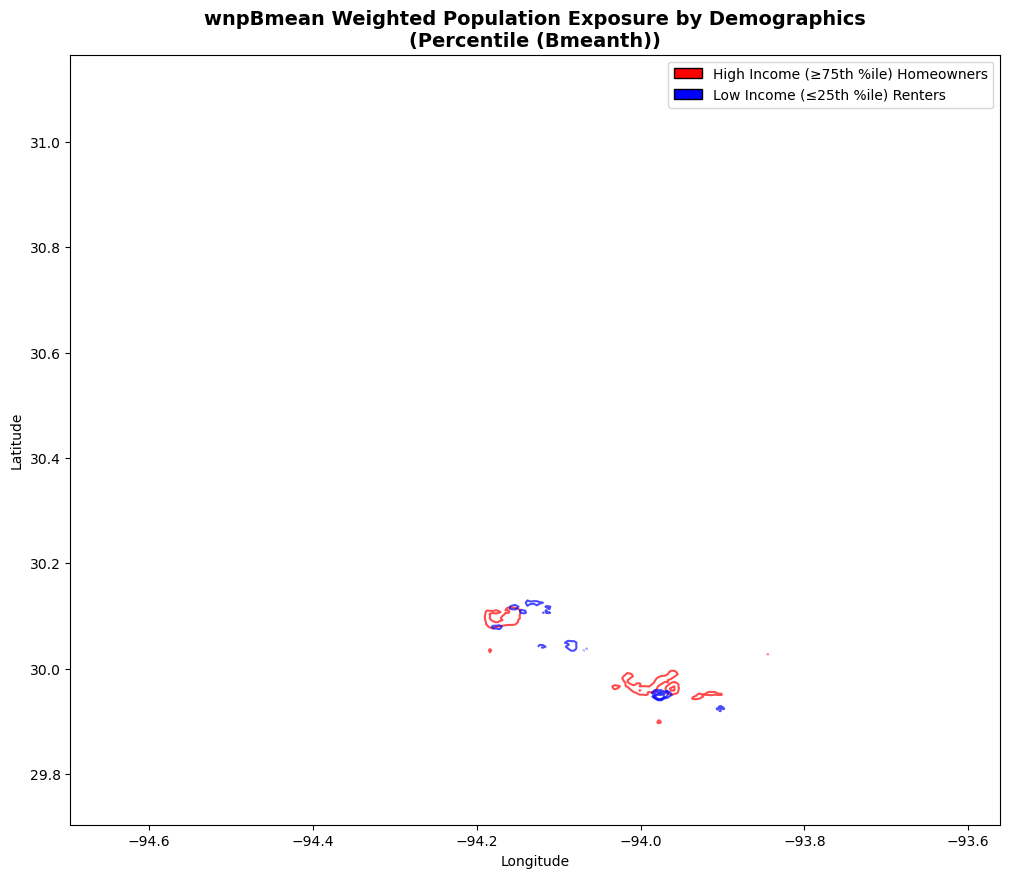

Converting contours to shapefiles...
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmean_low_income_renters.shp
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmean_high_income_homeowners.shp


In [12]:
# Create contours for direct weight method
print("\n" + "="*70)
print("Creating contours for DIRECT weight method (wnpBmean)")
print("="*70)
direct_contours = create_weighted_population_contours(
    popair_gdf,
    weight_column='wnpBmean',
    output_dir=programname,
    programname=programname,
    cell_size_m=cell_size_m,
    window_radius_m=window_radius_m,
    contour_increment=10,
    demographic_groups=demographic_groups,
    save_shapefile=True,
    create_folium_map=False  # Skip for speed, set to True to create interactive map
)


Creating contours for Z-SCORE weight method (wnpBmeanz3)
Building wnpBmeanz3 weighted contours for demographic groups (Z-score (3 SD))...
  Low income renters: 16557 households
  High income homeowners: 31884 households
Calculated 91 contour levels (increment=10): 10 to 910


c:\Users\nathanael99\AppData\Local\miniconda3\envs\ip1\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


Saved figure: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_weighted_demographics_wnpBmeanz3.png


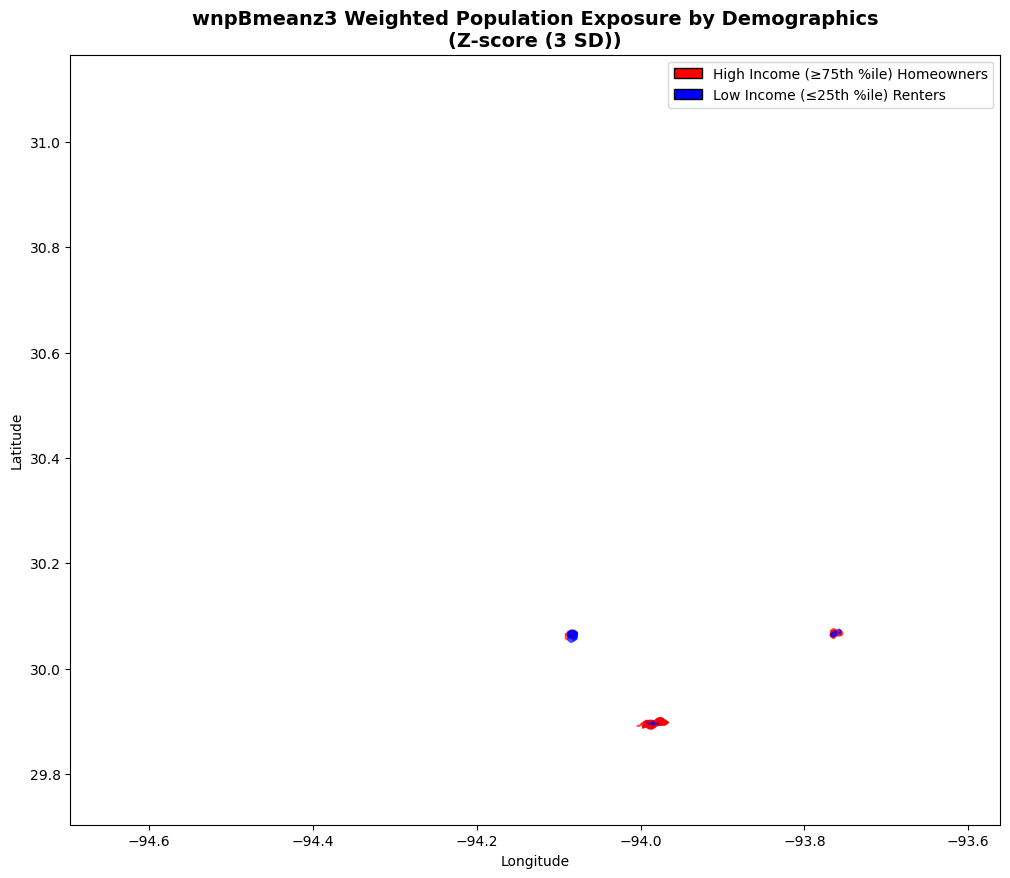

Converting contours to shapefiles...
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmeanz3_low_income_renters.shp
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmeanz3_high_income_homeowners.shp


In [13]:
# Create contours for z-score weight method
print("\n" + "="*70)
print("Creating contours for Z-SCORE weight method (wnpBmeanz3)")
print("="*70)
zscore_contours = create_weighted_population_contours(
    popair_gdf,
    weight_column='wnpBmeanz3',
    output_dir=programname,
    programname=programname,
    cell_size_m=cell_size_m,
    window_radius_m=window_radius_m,
    contour_increment=10,
    demographic_groups=demographic_groups,
    save_shapefile=True,
    create_folium_map=False
)


Creating contours for PERCENTILE weight method (wnpBmeanp75)
Building wnpBmeanp75 weighted contours for demographic groups (Percentile (75th))...
  Low income renters: 16557 households
  High income homeowners: 31884 households
Calculated 5 contour levels (increment=10): 10 to 50


c:\Users\nathanael99\AppData\Local\miniconda3\envs\ip1\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


Saved figure: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_weighted_demographics_wnpBmeanp75.png


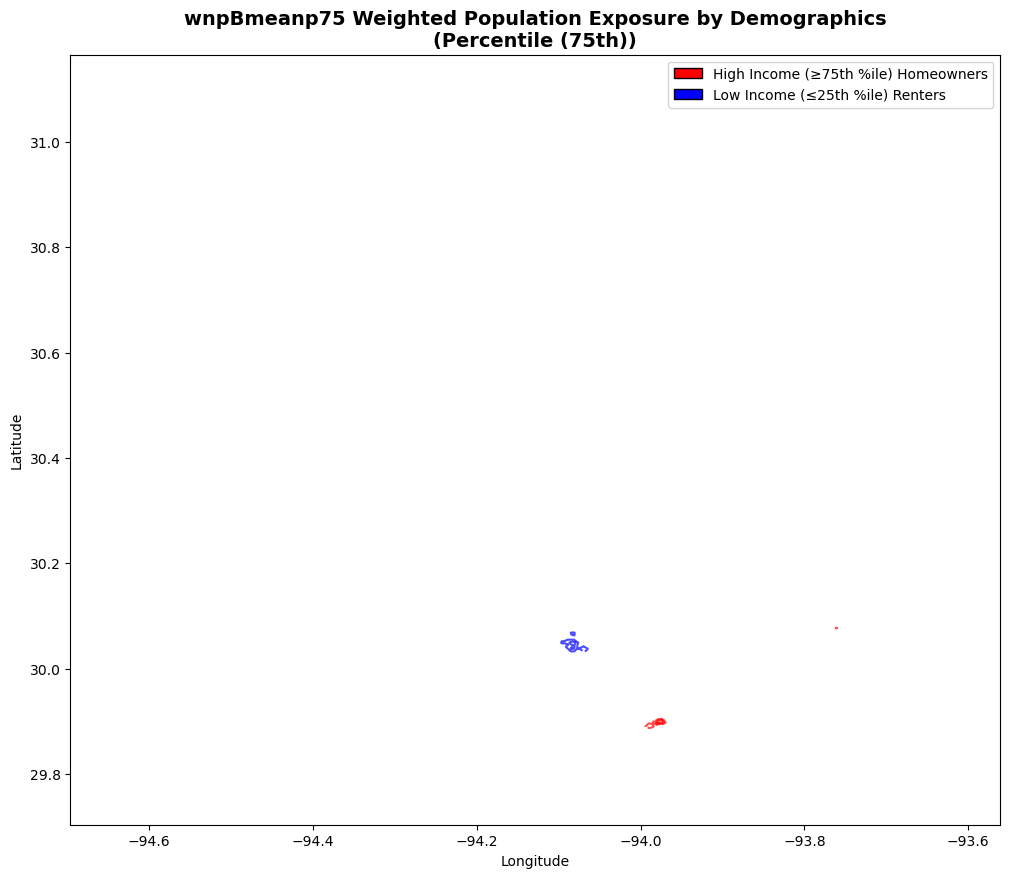

Converting contours to shapefiles...
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmeanp75_low_income_renters.shp
Saved shapefile: ip1_3av1_hotspotspopair\wnpBmeanp75_high_income_homeowners.shp


In [14]:
# Create contours for percentile weight method
print("\n" + "="*70)
print("Creating contours for PERCENTILE weight method (wnpBmeanp75)")
print("="*70)
percentile_contours = create_weighted_population_contours(
    popair_gdf,
    weight_column='wnpBmeanp75',
    output_dir=programname,
    programname=programname,
    cell_size_m=cell_size_m,
    window_radius_m=window_radius_m,
    contour_increment=10,
    demographic_groups=demographic_groups,
    save_shapefile=True,
    create_folium_map=False
)

#### 4.5.3 Interactive Comparison Map - All Methods for Low Income Renters

Single interactive map showing all three weighting methods as toggleable layers. Hover over contours to see weighted population values.

In [15]:
import folium

# Create single folium map with all three methods for low income renters
print("Creating interactive folium map with all three weighting methods...")

# Extract and convert contours to WGS84
direct_low = direct_contours["low_income_contours"].to_crs("EPSG:4326")
zscore_low = zscore_contours["low_income_contours"].to_crs("EPSG:4326")
percentile_low = percentile_contours["low_income_contours"].to_crs("EPSG:4326")

# Calculate map center
bounds = direct_low.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles='CartoDB positron'
)

# Define color schemes for each method
colors = {
    'direct': {'fill': '#FF6B6B', 'line': '#C92A2A', 'name': 'Direct'},
    'zscore': {'fill': '#4ECDC4', 'line': '#08A395', 'name': 'Z-Score (3 SD)'},
    'percentile': {'fill': '#FFE66D', 'line': '#D4A574', 'name': 'Percentile (75th)'}
}

# Add direct method layer
folium.GeoJson(
    direct_low,
    name='Direct: population × pollutant',
    style_function=lambda x: {
        'fillColor': colors['direct']['fill'],
        'color': colors['direct']['line'],
        'weight': 2,
        'fillOpacity': 0.5,
        'dashArray': '5, 5'
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['level'],
        aliases=['Weighted Population:'],
        labels=True
    )
).add_to(m)

# Add z-score method layer
folium.GeoJson(
    zscore_low,
    name='Z-Score (3 SD): areas >3σ above mean',
    style_function=lambda x: {
        'fillColor': colors['zscore']['fill'],
        'color': colors['zscore']['line'],
        'weight': 2,
        'fillOpacity': 0.5,
        'dashArray': '10, 5'
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['level'],
        aliases=['Weighted Population:'],
        labels=True
    )
).add_to(m)

# Add percentile method layer
folium.GeoJson(
    percentile_low,
    name='Percentile (75th): areas >75th %ile',
    style_function=lambda x: {
        'fillColor': colors['percentile']['fill'],
        'color': colors['percentile']['line'],
        'weight': 2,
        'fillOpacity': 0.5,
        'dashArray': ''
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['level'],
        aliases=['Weighted Population:'],
        labels=True
    )
).add_to(m)

# Add layer control
folium.LayerControl(position='topright', collapsed=False).add_to(m)

# Add title
title_html = '''
    <div style="position: fixed; 
                top: 10px; left: 50%; transform: translateX(-50%);
                width: auto; height: auto;
                background-color: white; border:3px solid #333;
                z-index:9999; font-size:16px; font-weight:bold;
                padding: 15px; border-radius: 8px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        Benzene-Weighted Exposure: Low Income Renters<br/>
        <span style="font-size:12px; font-weight:normal;">Compare weighting methods by toggling layers</span>
    </div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Add legend
legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 10px;
                width: 280px; height: auto;
                background-color: white; border:2px solid #333;
                z-index:9998; font-size:12px;
                padding: 10px; border-radius: 5px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        <p style="margin-top: 0; font-weight: bold;"><u>Weighting Methods</u></p>
        <p style="margin: 5px 0;"><span style="background-color: #FF6B6B; border: 2px solid #C92A2A; width: 20px; height: 20px; display: inline-block; border-radius: 3px;"></span> <b>Direct:</b> All population weighted</p>
        <p style="margin: 5px 0;"><span style="background-color: #4ECDC4; border: 2px solid #08A395; width: 20px; height: 20px; display: inline-block; border-radius: 3px;"></span> <b>Z-Score:</b> Extreme outliers only</p>
        <p style="margin: 5px 0;"><span style="background-color: #FFE66D; border: 2px solid #D4A574; width: 20px; height: 20px; display: inline-block; border-radius: 3px;"></span> <b>Percentile:</b> Upper quartile focus</p>
    </div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_output = os.path.join(programname, f"{programname}_all_methods_low_income_comparison.html")
m.save(map_output)
print(f"✓ Saved interactive map: {map_output}")
print(f"\nNotice:")
print(f"  - Direct method shows broadest hotspot areas (all population contributes)")
print(f"  - Z-Score method shows narrower focus (only extreme concentrations)")
print(f"  - Percentile method shows medium focus (above typical levels)")

# Display map
m

Creating interactive folium map with all three weighting methods...
✓ Saved interactive map: ip1_3av1_hotspotspopair\ip1_3av1_hotspotspopair_all_methods_low_income_comparison.html

Notice:
  - Direct method shows broadest hotspot areas (all population contributes)
  - Z-Score method shows narrower focus (only extreme concentrations)
  - Percentile method shows medium focus (above typical levels)


In [16]:
import numpy as np

print("Creating consolidated hotspot inventory from all three weighting methods...")
print("="*100)

# Extract contour polygons for low-income renters (vulnerability focus)
contour_sets = {
    'direct': (direct_contours["low_income_contours"], 'wnpBmean'),
    'zscore': (zscore_contours["low_income_contours"], 'wnpBmeanz3'),
    'percentile': (percentile_contours["low_income_contours"], 'wnpBmeanp75')
}

Creating consolidated hotspot inventory from all three weighting methods...


In [17]:
direct_contours["low_income_contours"].head()

,level,geometry
0,10.0,"POLYGON ((387300.765 3328193.564, 387095.82 33..."
1,10.0,"POLYGON ((392175.436 3331091.602, 392248.338 3..."
2,10.0,"POLYGON ((389978.144 3330976.893, 389612.957 3..."
3,10.0,"POLYGON ((392546.533 3331611.198, 392635.948 3..."
4,10.0,"POLYGON ((392914.74 3331837.524, 392840.158 33..."


#### 4.5.5 Merged Hotspots by Method with Statistics

Collapse overlapping polygons within each weighting method into unified geometries, then calculate comprehensive statistics for each merged hotspot. Combines all three methods into a single GeoDataFrame.

In [18]:
from shapely.ops import unary_union

print("Merging overlapping polygons by method and calculating statistics...")
print("="*100)

# Store original columns from popair_gdf for later reference
original_cols = popair_gdf.columns.tolist()

# Dictionary to store merged polygons and their statistics by method
merged_hotspots_list = []

for method_name, (contours, weight_col) in contour_sets.items():
    print(f"\n{method_name.upper()} METHOD ({weight_col}):")
    print("-" * 70)
    
    # Reproject contours to match popair_gdf CRS if needed
    if contours.crs != popair_gdf.crs:
        print(f"  Reprojecting from {contours.crs} to {popair_gdf.crs}...")
        contours_reprojected = contours.to_crs(popair_gdf.crs)
    else:
        contours_reprojected = contours
    
    # Merge all overlapping polygons within this method into unified geometry
    merged_geometry = unary_union(contours_reprojected.geometry)
    
    # Convert to list if single polygon (to handle both Polygon and MultiPolygon)
    if merged_geometry.geom_type == 'MultiPolygon':
        merged_polygons = list(merged_geometry.geoms)
    elif merged_geometry.geom_type == 'Polygon':
        merged_polygons = [merged_geometry]
    else:
        print(f"  Warning: Unexpected geometry type: {merged_geometry.geom_type}")
        continue
    
    print(f"  Merged into {len(merged_polygons)} unified polygon(s)")
    
    # For each merged polygon, calculate statistics from points within it
    for poly_idx, merged_poly in enumerate(merged_polygons, 1):
        merged_id = f"{weight_col}_merged_{poly_idx:03d}"
        
        # Create temporary GeoDataFrame for spatial join
        temp_gdf = gpd.GeoDataFrame({'temp_id': [0], 'geometry': [merged_poly]}, crs=popair_gdf.crs)
        
        # Use spatial join to find points that intersect this polygon
        points_joined = gpd.sjoin(popair_gdf, temp_gdf, how='inner', predicate='intersects')
        
        # Get unique points (remove duplicates from sjoin)
        if len(points_joined) == 0:
            print(f"    Polygon {poly_idx}: No points found inside, skipping")
            continue
        
        # Get the unique indices from the original GeoDataFrame
        point_indices = points_joined.index.unique()
        points_in_merged = popair_gdf.loc[point_indices]
        
        # Calculate demographic statistics
        total_population = points_in_merged['numprec'].sum()

        # Income statistics
        income_values = points_in_merged['randincome'].dropna()
        median_income = income_values.median() if len(income_values) > 0 else np.nan
        # percent poverty
        poverty_values = points_in_merged['poverty'].dropna()
        total_with_poverty_values = len(poverty_values)
        poverty_rate = (poverty_values.sum() / total_with_poverty_values * 100) if total_with_poverty_values > 0 else np.nan
        
        # Renter percentage - by population
        total_population_renters = points_in_merged.loc[points_in_merged['ownershp'] == 2, 'numprec'].sum()
        renter_pct = (total_population_renters / total_population * 100) if total_population > 0 else 0
        total_population_owners = points_in_merged.loc[points_in_merged['ownershp'] == 1, 'numprec'].sum()
        owner_pct = (total_population_owners / total_population * 100) if total_population > 0 else 0
        
        # Pollutant statistics
        hap_values = points_in_merged[pollutant].dropna()
        hap_mean = hap_values.mean() if len(hap_values) > 0 else np.nan
        hap_min = hap_values.min() if len(hap_values) > 0 else np.nan
        hap_max = hap_values.max() if len(hap_values) > 0 else np.nan
        
        # Weight statistics
        weight_values = points_in_merged[weight_col].dropna()
        weight_total = weight_values.sum()
        weight_mean = weight_values.mean() if len(weight_values) > 0 else np.nan
        weight_max = weight_values.max() if len(weight_values) > 0 else np.nan
        
        # Area calculation (convert to km²)
        # For WGS84, use an approximate conversion based on latitude
        # use equal area projection for accurate area calculation
        #merged_poly_projected = merged_poly.to_crs('EPSG:32615')  # UTM 15N
        area_m2 = merged_poly.area
        area_km2 = area_m2 / 1_000_000
        
        merged_hotspots_list.append({
            'hotspot_id': merged_id,
            'method': method_name,
            'weight_column': weight_col,
            'hap_pollutant': pollutant,
            'merged_polygon_num': poly_idx,
            'geometry': merged_poly,
            
            # Spatial stats
            'area_km2': area_km2,
            'area_m2': area_m2,
            
            # Demographic stats
            'total_population': total_population,
            'total_population_renters': total_population_renters,
            'total_population_owners': total_population_owners,
            'renter_pct': renter_pct,
            'owner_pct': owner_pct,
            
            # Income stats
            'median_income': median_income,
            'poverty_rate': poverty_rate,
            
            # HAP stats
            'hap_mean_conc': hap_mean,
            'hap_min_conc': hap_min,
            'hap_max_conc': hap_max,
            
            # Weight stats
            'weighted_pop_total': weight_total,
            'weighted_pop_mean': weight_mean,
            'weighted_pop_max': weight_max
        })
        
        print(f"    Polygon {poly_idx}: {total_population:,.0f} people, area={area_km2:.4f} km²")

# Create combined GeoDataFrame from all three methods
if len(merged_hotspots_list) > 0:
    merged_hotspots_df = pd.DataFrame(merged_hotspots_list)
    merged_hotspots_gdf = gpd.GeoDataFrame(merged_hotspots_df, geometry='geometry', crs=popair_gdf.crs)
else:
    print("\nWarning: No merged hotspots found with points inside! Creating empty GeoDataFrame.")
    merged_hotspots_gdf = gpd.GeoDataFrame(columns=['hotspot_id', 'method', 'weight_column', 'hap_pollutant', 'geometry'], crs=popair_gdf.crs)


Merging overlapping polygons by method and calculating statistics...

DIRECT METHOD (wnpBmean):
----------------------------------------------------------------------
  Reprojecting from EPSG:32615 to EPSG:4326...
  Merged into 14 unified polygon(s)


    Polygon 1: 3,804 people, area=0.0000 km²
    Polygon 2: 1,814 people, area=0.0000 km²
    Polygon 3: No points found inside, skipping
    Polygon 4: 16 people, area=0.0000 km²
    Polygon 5: 847 people, area=0.0000 km²
    Polygon 6: 39 people, area=0.0000 km²
    Polygon 7: 555 people, area=0.0000 km²
    Polygon 8: 2,257 people, area=0.0000 km²
    Polygon 9: 2,104 people, area=0.0000 km²
    Polygon 10: 81 people, area=0.0000 km²
    Polygon 11: 134 people, area=0.0000 km²
    Polygon 12: 515 people, area=0.0000 km²
    Polygon 13: 7,672 people, area=0.0000 km²
    Polygon 14: No points found inside, skipping

ZSCORE METHOD (wnpBmeanz3):
----------------------------------------------------------------------
  Reprojecting from EPSG:32615 to EPSG:4326...
  Merged into 2 unified polygon(s)
    Polygon 1: 767 people, area=0.0000 km²
    Polygon 2: 68 people, area=0.0000 km²

PERCENTILE METHOD (wnpBmeanp75):
----------------------------------------------------------------------
  Re

In [19]:
merged_hotspots_gdf.head()

,hotspot_id,method,weight_column,hap_pollutant,merged_polygon_num,geometry,area_km2,area_m2,total_population,total_population_renters,...,renter_pct,owner_pct,median_income,poverty_rate,hap_mean_conc,hap_min_conc,hap_max_conc,weighted_pop_total,weighted_pop_mean,weighted_pop_max
0,wnpBmean_merged_001,direct,wnpBmean,uifl_1km_Benzene_mean,1,"POLYGON ((-94.08493 30.03427, -94.08831 30.037...",1.848757e-10,0.000185,3804.0,2262.0,...,59.463722,39.537329,37837.0,30.949198,0.050864,0.044944,0.056266,193.072727,0.107502,1.887170
1,wnpBmean_merged_002,direct,wnpBmean,uifl_1km_Benzene_mean,2,"POLYGON ((-94.17609 30.07634, -94.17989 30.076...",6.067619e-11,0.000061,1814.0,1338.0,...,73.759647,26.240353,64126.0,14.045618,0.032226,0.031351,0.032244,58.454829,0.056974,0.225705
2,wnpBmean_merged_004,direct,wnpBmean,uifl_1km_Benzene_mean,4,"POLYGON ((-94.11152 30.10725, -94.11056 30.106...",3.894484e-12,0.000004,16.0,16.0,...,100.000000,0.000000,25733.0,66.666667,0.032871,0.032871,0.032871,0.525937,0.087656,0.131484
3,wnpBmean_merged_005,direct,wnpBmean,uifl_1km_Benzene_mean,5,"POLYGON ((-94.14571 30.11187, -94.14191 30.110...",3.499111e-11,0.000035,847.0,672.0,...,79.338843,20.661157,37573.0,28.438228,0.031892,0.031892,0.031892,27.012181,0.055240,0.223241
4,wnpBmean_merged_006,direct,wnpBmean,uifl_1km_Benzene_mean,6,"POLYGON ((-94.11532 30.11101, -94.11438 30.110...",3.837186e-12,0.000004,39.0,6.0,...,15.384615,84.615385,32158.5,25.000000,0.032871,0.032871,0.032871,1.281971,0.080123,0.164355


In [24]:

# Create interactive folium map with statistics popups
print("Creating interactive folium map of merged hotspots...")

# Load grid data
print("Loading grid data...")
grid_path = os.path.join("ip1_2bv2_airdata", "ip1_2bv2_airdata_grid_1km.gpkg")
grid_gdf = gpd.read_file(grid_path)
print(f"  Grid cells loaded: {len(grid_gdf)}")
print(f"  Grid columns: {grid_gdf.columns.tolist()}")

# Reproject grid to match map CRS if needed
if grid_gdf.crs != merged_hotspots_gdf.crs:
    grid_gdf = grid_gdf.to_crs(merged_hotspots_gdf.crs)

# Calculate 95th percentile for the pollutant
percentile_95 = grid_gdf[pollutant].quantile(0.95)
print(f"  95th percentile for {pollutant}: {percentile_95:.4f}")

# Calculate map center and bounds
bounds = merged_hotspots_gdf.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Create base map
hotspots_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles='CartoDB positron'
)

# Define colors by method
method_colors = {
    'direct': '#FF6B6B',      # Red
    'zscore': '#4ECDC4',      # Teal
    'percentile': '#FFE66D'   # Yellow
}

# Add each polygon to the map with statistics popup
for idx, row in merged_hotspots_gdf.iterrows():
    # Create popup content with statistics
    popup_html = f"""
    <html>
    <head><meta charset="utf-8" /></head>
    <body>
    <div style="font-family: Arial; font-size: 11px; width: 300px;">
        <h4 style="margin: 0 0 10px 0; border-bottom: 2px solid #333; padding-bottom: 5px;">
            {row['hotspot_id']}
        </h4>
        
        <b>Method:</b> {row['method'].upper()}<br/>
        <b>Weight Column:</b> {row['weight_column']}<br/>
        <hr style="margin: 8px 0; border: none; border-top: 1px solid #ddd;">
        
        <b>Spatial:</b><br/>
        &nbsp;&nbsp;Area: {row['area_km2']:.4f} km² ({row['area_m2']:,.0f} m²)<br/>
        
        <b>Population:</b><br/>
        &nbsp;&nbsp;Total: {row['total_population']:,.0f}<br/>
        &nbsp;&nbsp;Renters: {row['total_population_renters']:,.0f} ({row['renter_pct']:.1f}%)<br/>
        &nbsp;&nbsp;Owners: {row['total_population_owners']:,.0f} ({row['owner_pct']:.1f}%)<br/>
        
        <b>Income:</b><br/>
        &nbsp;&nbsp;Median: ${row['median_income']:,.0f}<br/>
        &nbsp;&nbsp;Poverty Rate: {row['poverty_rate']:.1f}%<br/>
        
        <b>{row['hap_pollutant']} Concentration (ppb):</b><br/>
        &nbsp;&nbsp;Mean: {row['hap_mean_conc']:.4f}<br/>
        &nbsp;&nbsp;Min: {row['hap_min_conc']:.4f}<br/>
        &nbsp;&nbsp;Max: {row['hap_max_conc']:.4f}<br/>
        
        <b>Weighted Population ({row['weight_column']}):</b><br/>
        &nbsp;&nbsp;Total: {row['weighted_pop_total']:,.1f}<br/>
        &nbsp;&nbsp;Mean: {row['weighted_pop_mean']:,.1f}<br/>
        &nbsp;&nbsp;Max: {row['weighted_pop_max']:,.1f}<br/>
    </div>
    </body>
    </html>
    """
    
    # Create popup using IFrame for proper HTML rendering
    iframe = folium.IFrame(html=popup_html, width=350, height=350)
    popup = folium.Popup(iframe, max_width=350)
    
    # Capture method for this row to use in style function
    method = row['method']
    color = method_colors[method]
    dash_array = '5, 5' if method == 'direct' else ('10, 5' if method == 'zscore' else '')
    
    # Add polygon to map
    folium.GeoJson(
        gpd.GeoSeries([row['geometry']]).__geo_interface__,
        style_function=lambda x, c=color, d=dash_array: {
            'fillColor': c,
            'color': c,
            'weight': 2,
            'fillOpacity': 0.5,
            'dashArray': d
        },
        popup=popup,
        tooltip=row['hotspot_id']
    ).add_to(hotspots_map)

# Extract pollutant name for display
pollutant_name = pollutant.split('_')[-2].capitalize()  # e.g., "Benzene" from "uifl_1km_Benzene_mean"

# Create and add grid layer (create as a separate feature group for toggling)
grid_layer = folium.FeatureGroup(name=f'{pollutant_name} Grid (1km)', show=False)

# Define colors for grid cells (colormap for values above 75th percentile)
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create colormap for grid values
grid_values = grid_gdf[pollutant].values
vmin = percentile_75
vmax = grid_values.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colormap = plt.get_cmap('YlOrRd')

# Add grid cells to the layer
for idx, row in grid_gdf.iterrows():
    cell_value = row[pollutant]
    
    # Create popup for grid cell
    grid_popup_html = f"""
    <html>
    <head><meta charset="utf-8" /></head>
    <body>
    <div style="font-family: Arial; font-size: 11px;">
        <b>{pollutant_name} Concentration:</b><br/>
        {cell_value:.4f} ppb
    </div>
    </body>
    </html>
    """
    
    iframe = folium.IFrame(html=grid_popup_html, width=200, height=80)
    popup = folium.Popup(iframe, max_width=200)
    
    # Determine color and fill based on percentile threshold
    if cell_value >= percentile_95:
        # Color cells above 95th percentile
        color_value = colormap(norm(cell_value))
        color_hex = mcolors.rgb2hex(color_value)
        fill_color = color_hex
        fill_opacity = 0.6
    else:
        # No fill for cells below 95th percentile
        fill_color = 'none'
        fill_opacity = 0
    
    # Add grid cell as GeoJson
    folium.GeoJson(
        gpd.GeoSeries([row['geometry']]).__geo_interface__,
        style_function=lambda x, fc=fill_color, fo=fill_opacity: {
            'fillColor': fc,
            'color': 'black',
            'weight': 0.1,
            'fillOpacity': fo
        },
        popup=popup,
        tooltip=f'{pollutant_name}: {cell_value:.4f} ppb'
    ).add_to(grid_layer)

# Add grid layer to map
grid_layer.add_to(hotspots_map)

# Add title with HAP name
title_html = f'''
    <div style="position: fixed; 
                top: 10px; left: 50%; transform: translateX(-50%);
                width: auto; height: auto;
                background-color: white; border:3px solid #333;
                z-index:9999; font-size:14px; font-weight:bold;
                padding: 15px; border-radius: 8px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        Merged Hotspots - {pollutant_name} Exposure<br/>
        <span style="font-size:11px; font-weight:normal;">Low Income Renters | Click polygons for detailed statistics</span>
    </div>
'''
hotspots_map.get_root().html.add_child(folium.Element(title_html))

# Add legend
legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 10px;
                width: 280px; height: auto;
                background-color: white; border:2px solid #333;
                z-index:9998; font-size:12px;
                padding: 15px; border-radius: 5px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        <p style="margin-top: 0; font-weight: bold;"><u>Weighting Methods</u></p>
        <p style="margin: 8px 0;">
            <span style="display:inline-block; width: 20px; height: 20px; background-color: #FF6B6B; border: 2px solid #C92A2A; border-radius: 3px; margin-right: 8px;"></span>
            <b>Direct:</b> population × pollutant
        </p>
        <p style="margin: 8px 0;">
            <span style="display:inline-block; width: 20px; height: 20px; background-color: #4ECDC4; border: 2px solid #08A395; border-radius: 3px; margin-right: 8px; border-style: dashed;"></span>
            <b>Z-Score:</b> extreme areas only
        </p>
        <p style="margin: 8px 0;">
            <span style="display:inline-block; width: 20px; height: 20px; background-color: #FFE66D; border: 2px solid #D4A574; border-radius: 3px; margin-right: 8px;"></span>
            <b>Percentile:</b> above 75th percentile
        </p>
    </div>
'''
hotspots_map.get_root().html.add_child(folium.Element(legend_html))

# Add layer control to toggle grid layer
folium.LayerControl(position='topright', collapsed=False).add_to(hotspots_map)

# Calculate study area summary statistics from ORIGINAL population data
study_area_population = popair_gdf['numprec'].sum()
study_area_renters = popair_gdf.loc[popair_gdf['ownershp'] == 2, 'numprec'].sum()
study_area_renter_pct = (study_area_renters / study_area_population * 100) if study_area_population > 0 else 0
study_area_median_income = popair_gdf['randincome'].median()
study_area_hap_median = popair_gdf[pollutant].median()
study_area_hap_min = popair_gdf[pollutant].min()
study_area_hap_max = popair_gdf[pollutant].max()
study_area_hap_p95 = popair_gdf[pollutant].quantile(0.95)

# Calculate study area summary statistics for population INSIDE hotspots
hotspots_points_joined = gpd.sjoin(popair_gdf, merged_hotspots_gdf, how='inner', predicate='intersects')
if len(hotspots_points_joined) > 0:
    hotspots_population = hotspots_points_joined['numprec'].sum()
    hotspots_renters = hotspots_points_joined.loc[hotspots_points_joined['ownershp'] == 2, 'numprec'].sum()
    hotspots_renter_pct = (hotspots_renters / hotspots_population * 100) if hotspots_population > 0 else 0
    hotspots_median_income = hotspots_points_joined['randincome'].median()
    hotspots_hap_median = hotspots_points_joined[pollutant].median()
    hotspots_hap_min = hotspots_points_joined[pollutant].min()
    hotspots_hap_max = hotspots_points_joined[pollutant].max()
    hotspots_hap_p95 = hotspots_points_joined[pollutant].quantile(0.95)
else:
    hotspots_population = 0
    hotspots_renters = 0
    hotspots_renter_pct = 0
    hotspots_median_income = 0
    hotspots_hap_median = 0
    hotspots_hap_min = 0
    hotspots_hap_max = 0
    hotspots_hap_p95 = 0

# Calculate total study area bounds
study_bounds = popair_gdf.total_bounds
study_area_km2 = (study_bounds[2] - study_bounds[0]) * (study_bounds[3] - study_bounds[1]) * 111 * 111 / 1_000_000  # Approximate area in km²

# Add summary statistics legend with STUDY AREA data
stats_html = f'''
    <div style="position: fixed; 
                bottom: 50px; left: 10px;
                width: 320px; height: auto;
                background-color: white; border:2px solid #333;
                z-index:9998; font-size:11px;
                padding: 12px; border-radius: 5px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        <p style="margin-top: 0; font-weight: bold; border-bottom: 1px solid #333; padding-bottom: 8px;"><u>Southeast Texas Summary (All Data)</u></p>
        <p style="margin: 4px 0;"><b>Total Population:</b> {study_area_population:,.0f}</p>
        <p style="margin: 4px 0;"><b>Renter Population:</b> {study_area_renters:,.0f} ({study_area_renter_pct:.1f}%)</p>
        <p style="margin: 4px 0;"><b>Median Income:</b> ${study_area_median_income:,.0f}</p>
        <p style="margin: 4px 0;"><b>{pollutant_name} Conc (ppb):</b><br/>
        &nbsp;&nbsp;Median: {study_area_hap_median:.4f}<br/>
        &nbsp;&nbsp;Min: {study_area_hap_min:.4f}<br/>
        &nbsp;&nbsp;Max: {study_area_hap_max:.4f}<br/>
        &nbsp;&nbsp;95th Percentile: {study_area_hap_p95:.4f}</p>
    </div>
'''
hotspots_map.get_root().html.add_child(folium.Element(stats_html))

# Add summary statistics legend for population INSIDE hotspots
hotspots_stats_html = f'''
    <div style="position: fixed; 
                bottom: 50px; left: 340px;
                width: 320px; height: auto;
                background-color: white; border:2px solid #333;
                z-index:9998; font-size:11px;
                padding: 12px; border-radius: 5px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.2);">
        <p style="margin-top: 0; font-weight: bold; border-bottom: 1px solid #333; padding-bottom: 8px;"><u>Hotspot Areas (In Polygons)</u></p>
        <p style="margin: 4px 0;"><b>Total Population:</b> {hotspots_population:,.0f}</p>
        <p style="margin: 4px 0;"><b>Renter Population:</b> {hotspots_renters:,.0f} ({hotspots_renter_pct:.1f}%)</p>
        <p style="margin: 4px 0;"><b>Median Income:</b> ${hotspots_median_income:,.0f}</p>
        <p style="margin: 4px 0;"><b>{pollutant_name} Conc (ppb):</b><br/>
        &nbsp;&nbsp;Median: {hotspots_hap_median:.4f}<br/>
        &nbsp;&nbsp;Min: {hotspots_hap_min:.4f}<br/>
        &nbsp;&nbsp;Max: {hotspots_hap_max:.4f}<br/>
        &nbsp;&nbsp;95th Percentile: {hotspots_hap_p95:.4f}</p>
        
    </div>
'''
hotspots_map.get_root().html.add_child(folium.Element(hotspots_stats_html))

# Save map
map_output_path = os.path.join(programname, f"{programname}_merged_hotspots_interactive.html")
hotspots_map.save(map_output_path)
print(f"✓ Interactive map saved: {map_output_path}")


Creating interactive folium map of merged hotspots...
Loading grid data...
  Grid cells loaded: 5184
  Grid columns: ['air_grid_id_1km', 'row_idx', 'col_idx', 'uifl_1km_Benzene_p75', 'uifl_1km_Benzene_p100', 'uifl_1km_Benzene_p95', 'uifl_1km_Benzene_p50', 'uifl_1km_Benzene_p25', 'uifl_1km_Benzene_p98', 'uifl_1km_Benzene_p90', 'uifl_1km_Benzene_mean', 'uifl_1km_Benzene_p99', 'uifl_1km_Acetonitrile_p90', 'uifl_1km_Acetonitrile_p98', 'uifl_1km_Acetonitrile_mean', 'uifl_1km_Acetonitrile_p50', 'uifl_1km_Acetonitrile_p75', 'uifl_1km_Acetonitrile_p99', 'uifl_1km_Acetonitrile_p25', 'uifl_1km_Acetonitrile_p95', 'uifl_1km_Acetonitrile_p100', 'uifl_1km_1,3-Butadiene_p100', 'uifl_1km_1,3-Butadiene_p90', 'uifl_1km_1,3-Butadiene_p98', 'uifl_1km_1,3-Butadiene_p95', 'uifl_1km_1,3-Butadiene_p75', 'uifl_1km_1,3-Butadiene_mean', 'uifl_1km_1,3-Butadiene_p50', 'uifl_1km_1,3-Butadiene_p25', 'uifl_1km_1,3-Butadiene_p99', 'uifl_1km_Styrene_p50', 'uifl_1km_Styrene_mean', 'uifl_1km_Styrene_p95', 'uifl_1km_Styre

#### THoughts
Probably need to do some form of Z-score weighting to account for different ranges of the chemical
Need to use the outer polygon and then add the total population to the polygon and then color code the values.

Need to save files with pollutant name

Need to have an option to show multiple pollutants

I would like to explore using different p values

Add option to overlay the CDC SVI

# Save results

In [ ]:
# Shapefile
shp_path_merged = os.path.join(programname, "hotspot_inventory_shapefiles", "merged_hotspots_by_method.shp")
merged_hotspots_gdf.to_file(shp_path_merged)

# GeoPackage
gpkg_path_merged = os.path.join(programname, "merged_hotspots_by_method.gpkg")
merged_hotspots_gdf.to_file(gpkg_path_merged, layer='merged_hotspots', driver='GPKG')

# CSV
csv_path_merged = os.path.join(programname, "merged_hotspots_by_method.csv")
merged_csv = merged_hotspots_gdf.copy()
merged_csv['geometry_wkt'] = merged_csv['geometry'].to_wkt()
merged_csv_out = merged_csv.drop('geometry', axis=1)
merged_csv_out.to_csv(csv_path_merged, index=False)